# Post-process trip data

## Install and import packages

In [1]:
#!pip install --upgrade seaborn
!pip install plotly

In [2]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd

## Data Inspection and Cleaning

### Load Synthetic Data

In [9]:
# Load trip data
trip_data = pd.read_csv('./Data_saved/kl_scheduling/EV_generated_data.csv')
# Add a column id to keep the number of the row
trip_data['id'] = trip_data.index
trip_data = trip_data[trip_data['event'] == 0].reset_index(drop=True)
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7371 entries, 0 to 7370
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   soc               7371 non-null   float64
 1   end_soc           7371 non-null   float64
 2   event             7371 non-null   int64  
 3   charge_mode       7371 non-null   int64  
 4   duration_minutes  7371 non-null   float64
 5   km_driven         7371 non-null   float64
 6   id                7371 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 403.2 KB


In [11]:
trip_data['odo'] = 0
trip_data['end_odo'] = trip_data['km_driven']
trip_data.info()
trip_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7371 entries, 0 to 7370
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   soc               7371 non-null   float64
 1   end_soc           7371 non-null   float64
 2   event             7371 non-null   int64  
 3   charge_mode       7371 non-null   int64  
 4   duration_minutes  7371 non-null   float64
 5   km_driven         7371 non-null   float64
 6   id                7371 non-null   int64  
 7   odo               7371 non-null   int64  
 8   end_odo           7371 non-null   float64
dtypes: float64(5), int64(4)
memory usage: 518.4 KB


,soc,end_soc,event,charge_mode,duration_minutes,km_driven,id,odo,end_odo
0,56.344369,54.408616,0,0,31.423168,17.293560,0,0,17.293560
1,55.177774,52.902505,0,0,17.648334,10.909423,1,0,10.909423
2,48.572843,45.049574,0,0,22.134289,9.632825,2,0,9.632825
3,47.376536,42.462787,0,0,32.515343,23.574494,3,0,23.574494
4,39.832996,38.491887,0,0,13.266637,8.467705,4,0,8.467705


### Data description

In [12]:
# Remove duplicates
trip_data = trip_data.drop_duplicates()

# Print how many records remain
print(f"Number of records after removing duplicates: {len(trip_data)}")

Number of records after removing duplicates: 7371


In [13]:
# Check for missing values and print records with them
nan_count = trip_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")

records_with_nan = trip_data[trip_data.isna().any(axis=1)]

length = len(records_with_nan)
if length > 0:
    print("\n🔍 Records with missing values:\n")
    records_with_nan.head(length)

| Features | NaN-counter |
soc                 0
end_soc             0
event               0
charge_mode         0
duration_minutes    0
km_driven           0
id                  0
odo                 0
end_odo             0
dtype: int64
|----------|-------------|


In [14]:
# statistics of the dataset for odo, end_odo, soc, end_soc
print("Statistics of the dataset:")
trip_data[['odo', 'end_odo', 'soc', 'end_soc']].describe().T

Statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
odo,7371.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
end_odo,7371.0,40.096425,36.982556,2.240611,14.612371,25.327613,53.732255,231.300437
soc,7371.0,56.826321,12.570176,15.790088,48.175419,57.170916,65.945875,88.315839
end_soc,7371.0,49.039144,12.434870,11.502438,40.445818,49.484199,57.809568,85.840403


In [15]:
# Add km_driven and discharge
#trip_data['km_driven'] = trip_data['end_odo'] - trip_data['odo']
trip_data['discharge'] = trip_data['soc'] - trip_data['end_soc']

# Add avg_speed in km/h 
trip_data['avg_speed'] = np.where(
    trip_data['duration_minutes'] > 0,
    (trip_data['end_odo'] - trip_data['odo']) / (trip_data['duration_minutes'] / 60),
    0
)

# Add km_per_perc_of_battery and discharge_per_km 
trip_data['km_per_perc_of_battery'] = trip_data.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)
trip_data['discharge_per_km'] = trip_data.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)

# Print statistics
print("📊 Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data['discharge'].describe())
print("\n🚗 Statistics on average speed:\n", trip_data['avg_speed'].describe())
p99_speed = trip_data['avg_speed'].quantile(0.99)
print(f"99th percentile of average speed: {p99_speed:.2f} km/h")
print("\n🛢️ Statistics on km per percentage of battery:\n", trip_data['km_per_perc_of_battery'].describe())
print("\n🔋 Statistics on discharge per km:\n", trip_data['discharge_per_km'].describe())

📊 Statistics on driven km:
 count    7371.000000
mean       40.096425
std        36.982556
min         2.240611
25%        14.612371
50%        25.327613
75%        53.732255
max       231.300437
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    7371.000000
mean        7.787177
std         8.143687
min       -19.469220
25%         2.518929
50%         5.674524
75%        11.976580
max        41.348675
Name: discharge, dtype: float64

🚗 Statistics on average speed:
 count    7371.000000
mean       36.065214
std        10.326419
min         5.232389
25%        31.905306
50%        38.346377
75%        43.024165
max        61.509217
Name: avg_speed, dtype: float64
99th percentile of average speed: 52.91 km/h

🛢️ Statistics on km per percentage of battery:
 count    7371.000000
mean        4.114926
std        47.124942
min     -2014.122101
25%         3.827713
50%         4.805997
75%         5.760936
max      1372.858362
Name: km_per_perc_of_battery, dtype: float64

🔋 

### Identify and remove anomalous records

In [16]:
# Identify snapshot records (data with no changes in soc, odo, and duration)
snapshot_records = trip_data[(trip_data['soc'] == trip_data['end_soc']) & (trip_data['end_odo'] == trip_data['odo']) & (trip_data['duration_minutes'] == 0)]

length = snapshot_records.shape[0]
print(f"Number of snapshot records: {length}")
if length > 0:
    snapshot_records.head(length)

Number of snapshot records: 0


In [17]:
# Remove snapshot records
trip_data = trip_data.drop(snapshot_records.index).reset_index(drop=True)

In [18]:
# Identify records with negative duration
negative_duration_records = trip_data[(trip_data['duration_minutes'] <= 0)]

length = negative_duration_records.shape[0]
print(f"Number of records with negative duration: {length}")
if length > 0:  
    negative_duration_records.head(length)

Number of records with negative duration: 0


In [19]:
# Remove records with negative duration
trip_data = trip_data.drop(negative_duration_records.index).reset_index(drop=True)

In [20]:
# Identify stationary records (data with no changes in soc, odo, but positive duration)
stationary_records = trip_data[(trip_data['soc'] == trip_data['end_soc']) & (trip_data['end_odo'] == trip_data['odo']) & (trip_data['duration_minutes'] > 0)]

length = stationary_records.shape[0]
print(f"Number of stationary records: {length}")
if length > 0:
    stationary_records.head(length)

Number of stationary records: 0


In [21]:
# Remove stationary records
trip_data = trip_data.drop(stationary_records.index).reset_index(drop=True)

In [22]:
# Identify records with (end_soc) [%] > (soc + 1) [%]   
anomalous_soc_records = trip_data[(trip_data['end_soc'] > trip_data['soc'] + 1)]

length = anomalous_soc_records.shape[0]
print(f"Number of anomalous soc records: {length}")
if length > 0:
    anomalous_soc_records.head(length)

Number of anomalous soc records: 517


In [23]:
# Remove anomalous soc records
trip_data = trip_data.drop(anomalous_soc_records.index).reset_index(drop=True)

In [24]:
# Identify anomalous movement records (end_odo < odo)
anomalous_movement_records = trip_data[(trip_data['end_odo'] < trip_data['odo'])]

length = anomalous_movement_records.shape[0]
print(f"Number of anomalous movement records: {length}")
if length > 0:
    anomalous_movement_records.head(length)

Number of anomalous movement records: 0


In [25]:
# Remove anomalous movement records
trip_data = trip_data.drop(anomalous_movement_records.index).reset_index(drop=True)

In [26]:
# Identify records with high average speed 
#######################
SPEED_THRESHOLD = 130 #
#######################

anomalous_speed_records = trip_data[(trip_data['avg_speed'] > SPEED_THRESHOLD)]

length = anomalous_speed_records.shape[0]
print(f"Number of records with avg_speed > {SPEED_THRESHOLD} km/h: {length}")
if length > 0:
    anomalous_speed_records.head(length)

Number of records with avg_speed > 130 km/h: 0


In [27]:
# Remove anomalous speed records
trip_data = trip_data.drop(anomalous_speed_records.index).reset_index(drop=True)

In [28]:
# Identify anomalous records with high discharge per km
############################
MAX_DISCHARGE_PER_KM = 0.9 #
############################

anomalous_discharge_records = trip_data[(trip_data['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")

if length > 0:
    anomalous_discharge_records.head(length)

Number of anomalous discharge records: 0


In [29]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [30]:
# Identify anomalous records with high km per percentage of battery discharge 
############################
MAX_KM_PER_DISCHARGE = 20 #
############################

anomalous_discharge_records = trip_data[trip_data['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")

if length > 0:
    anomalous_discharge_records.head(length)

Number of anomalous discharge records: 153


In [31]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [32]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6701 entries, 0 to 6700
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   soc                     6701 non-null   float64
 1   end_soc                 6701 non-null   float64
 2   event                   6701 non-null   int64  
 3   charge_mode             6701 non-null   int64  
 4   duration_minutes        6701 non-null   float64
 5   km_driven               6701 non-null   float64
 6   id                      6701 non-null   int64  
 7   odo                     6701 non-null   int64  
 8   end_odo                 6701 non-null   float64
 9   discharge               6701 non-null   float64
 10  avg_speed               6701 non-null   float64
 11  km_per_perc_of_battery  6701 non-null   float64
 12  discharge_per_km        6701 non-null   float64
dtypes: float64(9), int64(4)
memory usage: 680.7 KB


## Data Visualization and Comparative Analysis

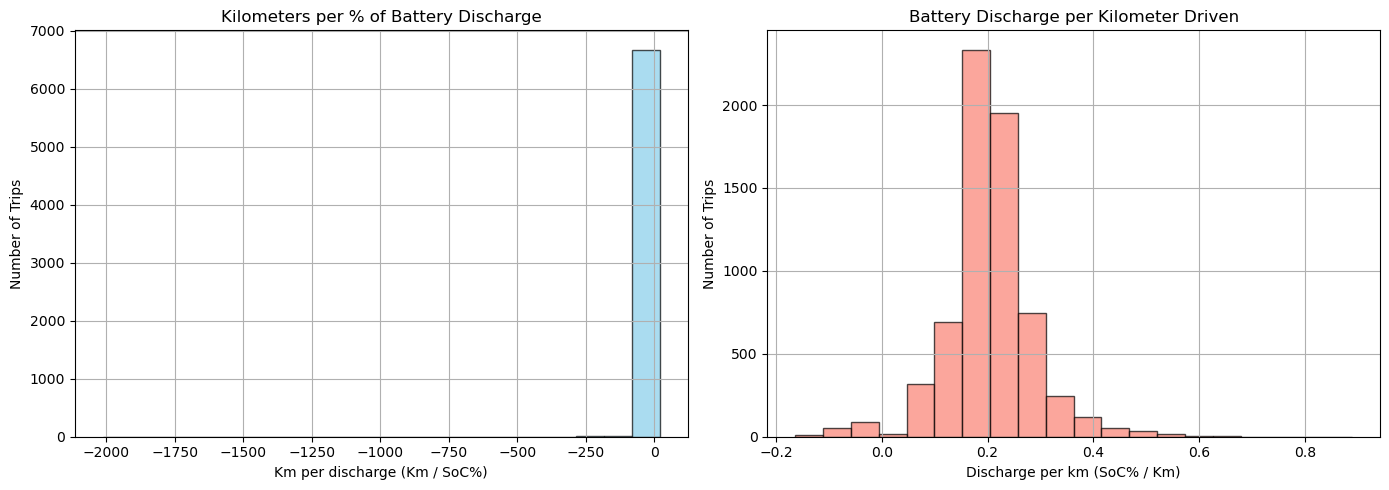

In [33]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kilometers per % battery
axes[0].hist(
    trip_data['km_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Kilometers per % of Battery Discharge')
axes[0].set_xlabel('Km per discharge (Km / SoC%)')
axes[0].set_ylabel('Number of Trips')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    trip_data['discharge_per_km'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery Discharge per Kilometer Driven')
axes[1].set_xlabel('Discharge per km (SoC% / Km)')
axes[1].set_ylabel('Number of Trips')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [26]:
trip_data.head()

,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
0,9653.721091,9937.558535,75.634072,61.208178,0,0,132.014333,283.837444,14.425895,129.003012,19.675552,0.050824
1,9558.162493,9593.817201,66.041105,56.048304,0,0,57.031109,35.654708,9.992802,37.510799,3.568039,0.280266
2,10519.927756,10670.866991,72.969506,54.648306,0,0,130.466465,150.939235,18.321200,69.415187,8.238502,0.121381
3,13274.212933,13451.668479,66.352206,49.606460,0,0,119.660002,177.455545,16.745746,88.979881,10.597052,0.094366
4,13080.207145,13219.792618,68.621724,59.826910,0,0,79.200977,139.585474,8.794814,105.745267,15.871339,0.063007


In [34]:
max_km = trip_data['km_per_perc_of_battery'].max()
max_km_row = trip_data[trip_data['km_per_perc_of_battery'] == max_km]

print("\n Record with maximum Km/SoC driven:\n")
max_km_row.head()


 Record with maximum Km/SoC driven:



,soc,end_soc,event,charge_mode,duration_minutes,km_driven,id,odo,end_odo,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
3659,39.050474,38.242149,0,0,25.900717,16.139945,6129,0,16.139945,0.808325,37.388798,19.967142,0.050082


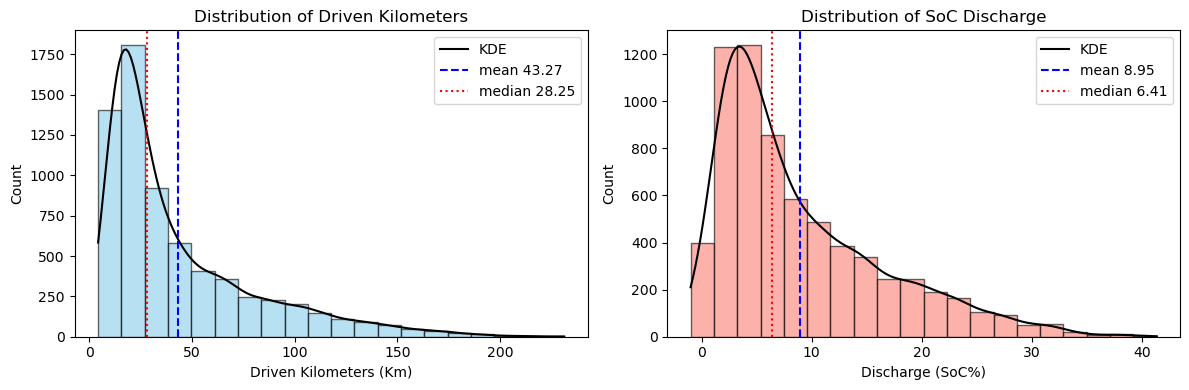

In [35]:
def plot_hist_with_kde(series, ax, color, title, xlabel, bins=20):
    # Ensure numeric and drop NaNs / infs
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if y.size == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center')
        ax.set_title(title)
        return

    # Histogram (counts)
    counts, bin_edges, _ = ax.hist(y, bins=bins, density=False,
                                   alpha=0.6, color=color, edgecolor='black')

    # KDE scaled to match histogram counts
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(y)
        x_grid = np.linspace(y.min(), y.max(), 200)
        # scale KDE to counts
        kde_vals = kde(x_grid) * len(y) * (bin_edges[1] - bin_edges[0])
        ax.plot(x_grid, kde_vals, color='k', lw=1.5, label='KDE')
    except ImportError:
        pass  # skip KDE if SciPy not available

    # Mean & median vertical lines
    ax.axvline(y.mean(), color='blue', linestyle='--', label=f'mean {y.mean():.2f}')
    ax.axvline(np.median(y), color='red', linestyle=':', label=f'median {np.median(y):.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_hist_with_kde(trip_data.get('km_driven', pd.Series(dtype=float)), axes[0],
                   color='skyblue', title='Distribution of Driven Kilometers', xlabel='Driven Kilometers (Km)')

plot_hist_with_kde(trip_data.get('discharge', pd.Series(dtype=float)), axes[1],
                   color='salmon', title='Distribution of SoC Discharge', xlabel='Discharge (SoC%)')

plt.tight_layout()
plt.show()

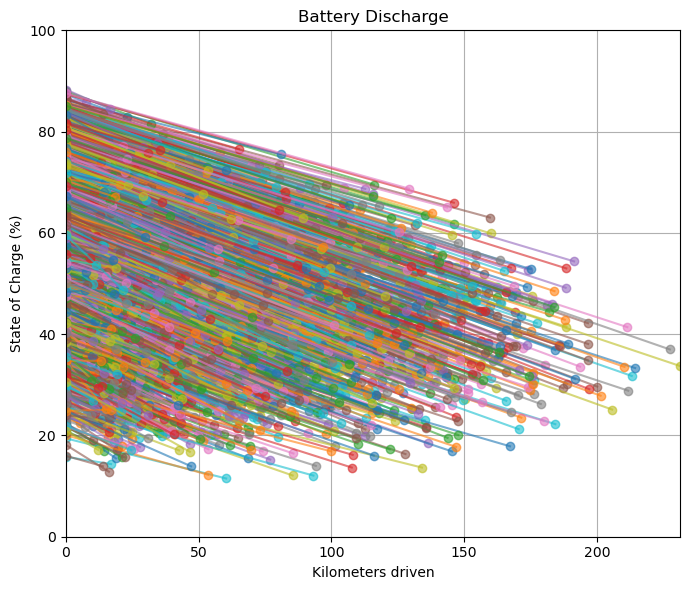

In [36]:
# Max km for x-axis scaling
max_km_driven = trip_data['km_driven'].max()

# --- Matplotlib version ---
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in trip_data.iterrows():
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.6)

ax.set_title('Battery Discharge')
ax.set_xlabel('Kilometers driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True)

plt.tight_layout()
plt.show()


# --- Plotly version ---
colors = px.colors.qualitative.Plotly
fig = go.Figure()

for color_idx, (_, row) in enumerate(trip_data.reset_index().iterrows()):
    fig.add_trace(
        go.Scatter(
            x=[0, row['km_driven']],
            y=[row['soc'], row['end_soc']],
            mode='lines+markers',
            opacity=0.5,
            line=dict(color=colors[color_idx % len(colors)], width=2),
            marker=dict(size=6),
            name=f"Trip {row['index']}",
            hovertemplate=(
                f"Trip index: {row['index']}<br>"
                f"SOC start: {row['soc']}%<br>"
                f"SOC end: {row['end_soc']}%<br>"
                f"Km driven: {row['km_driven']} km<br>"
            )
        )
    )

fig.update_xaxes(title_text='Kilometers driven', range=[0, max_km_driven])
fig.update_yaxes(title_text='State of Charge (%)', range=[0, 100])

fig.update_layout(
    title="Battery Discharge",
    height=500,
    width=700,
    showlegend=False,
    hovermode='closest'
)

fig.show()


In [37]:
trip_data['discharge_per_km'].describe()

count    6701.000000
mean        0.204535
std         0.083330
min        -0.163783
25%         0.169023
50%         0.202031
75%         0.238903
max         0.889431
Name: discharge_per_km, dtype: float64

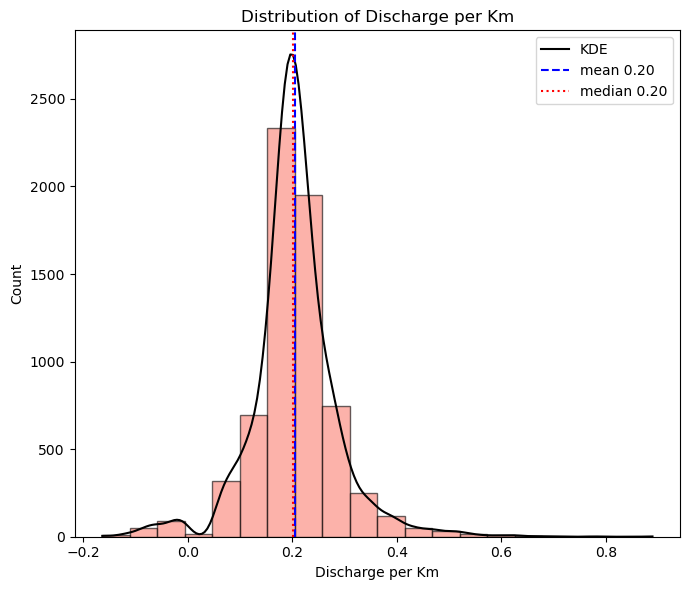

In [38]:
# --- Distribution of Discharge per Km ---
fig, ax = plt.subplots(figsize=(7, 6))

plot_hist_with_kde(trip_data.get('discharge_per_km', pd.Series(dtype=float)), ax,
                   color='salmon', title='Distribution of Discharge per Km', xlabel='Discharge per Km')


plt.tight_layout()
plt.show()

## Original dataset

In [39]:
trip_data_original = pd.read_csv('./datasets/vehicle_2_47174e+18.csv')
trip_data_original = trip_data_original[trip_data_original['event'] == 'trip'].reset_index(drop=True)
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 527 entries, 0 to 526
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          527 non-null    float64
 1   timestamp    527 non-null    object 
 2   end_time     527 non-null    object 
 3   odo          527 non-null    float64
 4   end_odo      527 non-null    float64
 5   soc          527 non-null    float64
 6   end_soc      527 non-null    float64
 7   event        527 non-null    object 
 8   charge_mode  527 non-null    object 
dtypes: float64(5), object(4)
memory usage: 37.2+ KB


In [40]:
# Remove duplicates
trip_data_original = trip_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(trip_data_original)}")

trip_data_original['km_driven'] = trip_data_original['end_odo'] - trip_data_original['odo']
trip_data_original['discharge'] = trip_data_original['soc'] - trip_data_original['end_soc']

print("📊 Statistics on driven km:\n", trip_data_original['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data_original['discharge'].describe())

Number of rows after removing duplicates: 527
📊 Statistics on driven km:
 count    527.000000
mean      41.088105
std       50.508957
min        0.000000
25%        8.171872
50%       15.937500
75%       61.273435
max      378.187500
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    527.00000
mean       7.90797
std        9.98188
min       -0.40000
25%        1.20000
50%        3.10000
75%       11.75000
max       74.60000
Name: discharge, dtype: float64


In [41]:
trip_data_original['km_per_perc_of_battery'] = trip_data_original.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

trip_data_original['discharge_per_km'] = trip_data_original.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)


In [42]:
MAX_DISCHARGE_PER_KM = 0.9
##########################################################



anomalous_rows_trip = trip_data_original[(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
print(f"Number of anamalous rows: {anomalous_rows_trip.shape[0]}")

trip_data_original = trip_data_original[~(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)].reset_index(drop=True)
anomalous_rows_trip.head(len(anomalous_rows_trip ))

Number of anamalous rows: 6


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
16,-2.471740e+18,2021-04-29 19:05:00,2021-04-29 19:16:00,2419.812500,2419.84375,25.8,25.4,trip,0,0.031250,0.4,0.078125,12.800000
33,-2.471740e+18,2021-05-02 16:11:00,2021-05-02 16:53:00,2609.625000,2609.65625,34.1,33.3,trip,0,0.031250,0.8,0.039062,25.600000
55,-2.471740e+18,2021-05-05 17:40:00,2021-05-05 18:48:00,2875.703125,2875.75000,39.6,38.8,trip,0,0.046875,0.8,0.058594,17.066667
269,-2.471740e+18,2021-06-08 18:54:00,2021-06-08 18:56:00,11825.156250,11825.65625,50.5,49.8,trip,0,0.500000,0.7,0.714286,1.400000
446,-2.471740e+18,2021-07-11 19:53:00,2021-07-11 20:06:00,21003.656250,21009.34375,62.0,54.0,trip,0,5.687500,8.0,0.710938,1.406593
512,-2.471740e+18,2021-07-17 23:55:00,2021-07-18 01:05:00,23272.312500,23272.64063,41.9,39.2,trip,0,0.328130,2.7,0.121530,8.228446


In [43]:
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   vin                     521 non-null    float64
 1   timestamp               521 non-null    object 
 2   end_time                521 non-null    object 
 3   odo                     521 non-null    float64
 4   end_odo                 521 non-null    float64
 5   soc                     521 non-null    float64
 6   end_soc                 521 non-null    float64
 7   event                   521 non-null    object 
 8   charge_mode             521 non-null    object 
 9   km_driven               521 non-null    float64
 10  discharge               521 non-null    float64
 11  km_per_perc_of_battery  521 non-null    float64
 12  discharge_per_km        521 non-null    float64
dtypes: float64(9), object(4)
memory usage: 53.0+ KB


In [44]:
trip_data_original['discharge_per_km'].describe()

count    521.000000
mean       0.170649
std        0.086673
min       -0.474074
25%        0.146958
50%        0.182206
75%        0.203904
max        0.752941
Name: discharge_per_km, dtype: float64

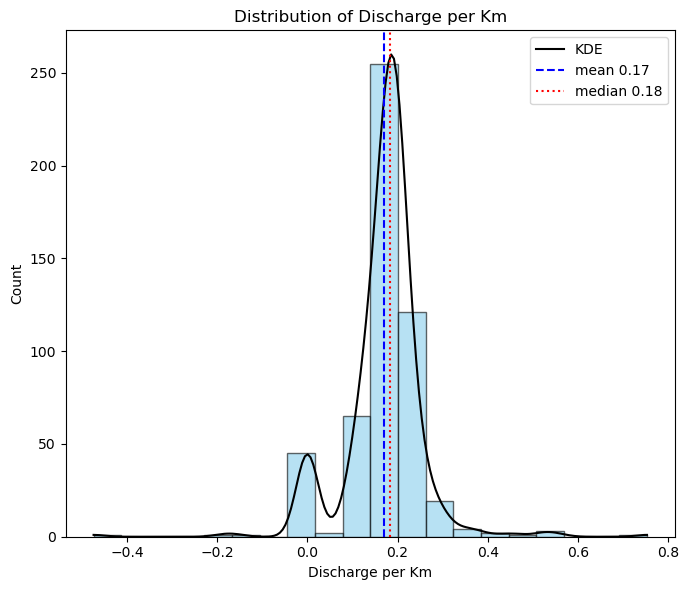

In [45]:
# --- Distribution of Discharge per Km ---
fig, ax = plt.subplots(figsize=(7, 6))

plot_hist_with_kde(trip_data_original.get('discharge_per_km', pd.Series(dtype=float)), ax,
                   color='skyblue', title='Distribution of Discharge per Km', xlabel='Discharge per Km')


plt.tight_layout()
plt.show()